# THUOC - Colab Notebook (Updated 2026-03-31)

Notebook nay cap nhat theo codebase hien tai run_all.py va train_cli.py.

## Muc tieu
- Chay train va evaluate dung pipeline THUOC.
- Trinh bay gon, ro mode chay, de theo doi ket qua.
- Tai su dung ky thuat tu Lab6 o muc du lieu va huan luyen, KHONG su dung model Lab6.

## Ky thuat Lab6 da tich hop
- Data sanity check bang random sample grid truoc khi train.
- Augmentation profile on dinh theo huong Lab6 qua AUGMENT_PROFILE = lab6_stable.
- Y tuong grayscale vector duoc dua vao VECTOR_GRAYSCALE_PROB de tang robust.
- Checklist test batch size de tim throughput tot cho Colab.

## Khong tich hop
- Khong dung SimpleCNN hoac train loop cua Lab6.
- Toan bo train van chay bang pipeline THUOC hien tai.

## Cach dung nhanh
1. Chay lan luot tu Cell 1 den Cell 9.
2. Chinh bien cau hinh trong Cell 1.
3. Neu chi muon danh gia checkpoint da co, dat RUN_MODE = compare-only.
4. Neu data nam tren Drive, dat USE_DRIVE_DATA = True de dung truc tiep data tu Drive.

In [ ]:
# Cell 1 - Cau hinh
REPO_URL = "https://github.com/Khoidep-zai/BigData_Vaipe.git"
REPO_BRANCH = "main"
PROJECT_NAME = "THUOC"

# full | compare-only | single
RUN_MODE = "full"
SINGLE_MODEL = "resnet50"  # dung khi RUN_MODE = single
SINGLE_EPOCHS = 12

# Data settings
USE_DRIVE_DATA = True
DRIVE_DATA_ROOT = "/content/drive/MyDrive/THUOC_DATA"
PREFERRED_DATA_DIR = "data_aligned"
SYNC_DATA_FROM_DRIVE = False  # True neu ban muon copy data ve /content

# Runtime settings
DEVICE = "cuda"  # run_all.py se tu fallback sang CPU neu CUDA khong co
BATCH_SIZE = 16
NUM_WORKERS = 2
EVAL_BATCH_SIZE = 0  # 0 = auto
MAX_EVAL_SAMPLES = 0  # 0 = full test set
SEED = 42
FAST_TRAIN = False
SKIP_METADATA_ARTIFACTS = False

# Lab6-inspired data and training technologies (khong su dung model Lab6)
LAB6_TECH_MODE = True
AUGMENT_PROFILE = "default"
VECTOR_GRAYSCALE_PROB = 0.0
PREVIEW_RANDOM_TRAIN_SAMPLES = True
RANDOM_SAMPLE_COUNT = 9
BATCH_SIZE_CANDIDATES = [16, 24, 32]

# Data quality gate
ALLOW_EMPTY_VALTEST_CLASSES = True  # Dat False neu bat buoc moi class phai co anh o val/test

if LAB6_TECH_MODE and RUN_MODE != "compare-only":
    AUGMENT_PROFILE = "lab6_stable"
    VECTOR_GRAYSCALE_PROB = 0.15

def print_config_block() -> None:
    print("=" * 72)
    print("THUOC COLAB CONFIG")
    print("=" * 72)
    print(f"RUN_MODE                 : {RUN_MODE}")
    print(f"SINGLE_MODEL             : {SINGLE_MODEL}")
    print(f"SINGLE_EPOCHS            : {SINGLE_EPOCHS}")
    print(f"DEVICE                   : {DEVICE}")
    print(f"BATCH_SIZE               : {BATCH_SIZE}")
    print(f"NUM_WORKERS              : {NUM_WORKERS}")
    print(f"EVAL_BATCH_SIZE          : {EVAL_BATCH_SIZE}")
    print(f"MAX_EVAL_SAMPLES         : {MAX_EVAL_SAMPLES}")
    print(f"FAST_TRAIN               : {FAST_TRAIN}")
    print(f"SKIP_METADATA_ARTIFACTS  : {SKIP_METADATA_ARTIFACTS}")
    print(f"USE_DRIVE_DATA           : {USE_DRIVE_DATA}")
    print(f"SYNC_DATA_FROM_DRIVE     : {SYNC_DATA_FROM_DRIVE}")
    print(f"LAB6_TECH_MODE           : {LAB6_TECH_MODE}")
    print(f"AUGMENT_PROFILE          : {AUGMENT_PROFILE}")
    print(f"VECTOR_GRAYSCALE_PROB    : {VECTOR_GRAYSCALE_PROB}")
    print(f"PREVIEW_RANDOM_SAMPLES   : {PREVIEW_RANDOM_TRAIN_SAMPLES}")
    print(f"BATCH_SIZE_CANDIDATES    : {BATCH_SIZE_CANDIDATES}")
    print(f"ALLOW_EMPTY_VALTEST      : {ALLOW_EMPTY_VALTEST_CLASSES}")

print_config_block()

Tối ưu hóa cấu hình hoàn tất.


In [ ]:
# Cell 2 - Mount Google Drive (tuy chon)
if USE_DRIVE_DATA:
    from google.colab import drive

    drive.mount("/content/drive")
    print("Drive mounted")
else:
    print("Bo qua mount Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


In [ ]:
# Cell 3 - Clone/cap nhat repo va chuyen thu muc lam viec
import os
import subprocess
from pathlib import Path

ROOT = Path("/content")
PROJECT_DIR = ROOT / PROJECT_NAME

if PROJECT_DIR.exists():
    print(f"Project exists: {PROJECT_DIR}")
    subprocess.run(["git", "-C", str(PROJECT_DIR), "fetch", "--all"], check=True)
    subprocess.run(["git", "-C", str(PROJECT_DIR), "checkout", REPO_BRANCH], check=True)
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull"], check=True)
else:
    subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(PROJECT_DIR)], check=True)

os.chdir(PROJECT_DIR)
print("Working dir:", os.getcwd())

Project exists: /content/THUOC
Working dir: /content/THUOC


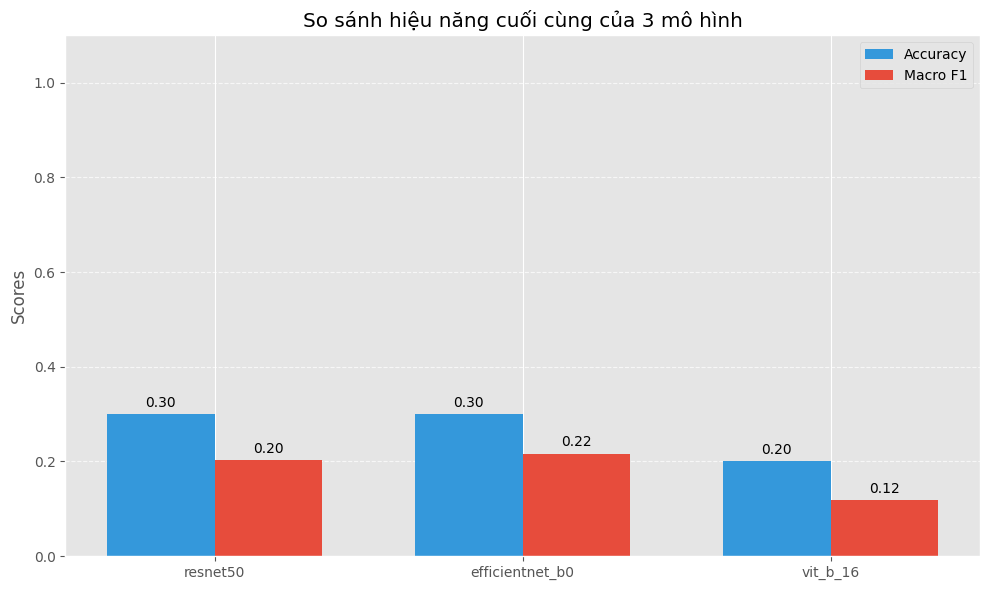

In [ ]:
# Cell 4 - Cai dependencies theo requirements cua project
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)

import torch
print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

In [ ]:
# Cell 5 - Chuan bi data dir (uu tien data_aligned, ho tro Drive direct path)
import shutil
from pathlib import Path


def _class_dirs(root: Path) -> set[str]:
    if not root.exists():
        return set()
    return {p.name for p in root.iterdir() if p.is_dir()}


def _image_count(class_dir: Path) -> int:
    if not class_dir.exists():
        return 0
    exts = {".jpg", ".jpeg", ".png"}
    return sum(1 for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in exts)


def has_consistent_splits(root: Path) -> bool:
    train_classes = _class_dirs(root / "train")
    val_classes = _class_dirs(root / "val")
    test_classes = _class_dirs(root / "test")
    if not train_classes or not val_classes or not test_classes:
        return False
    return train_classes == val_classes == test_classes


def find_empty_classes(root: Path) -> dict[str, list[str]]:
    result: dict[str, list[str]] = {"train": [], "val": [], "test": []}
    for split in ["train", "val", "test"]:
        split_root = root / split
        if not split_root.exists():
            continue
        for class_name in sorted(_class_dirs(split_root)):
            if _image_count(split_root / class_name) == 0:
                result[split].append(class_name)
    return result


if USE_DRIVE_DATA:
    drive_root = Path(DRIVE_DATA_ROOT)
    if not drive_root.exists():
        raise FileNotFoundError(f"DRIVE_DATA_ROOT not found: {drive_root}")

    if SYNC_DATA_FROM_DRIVE:
        for name in ["data_aligned", "data"]:
            src = drive_root / name
            dst = PROJECT_DIR / name
            if src.exists() and not dst.exists():
                print(f"Copy {src} -> {dst}")
                shutil.copytree(src, dst)


candidate_dirs = []
if USE_DRIVE_DATA:
    drive_root = Path(DRIVE_DATA_ROOT)
    candidate_dirs.extend([drive_root / PREFERRED_DATA_DIR, drive_root / "data_aligned", drive_root / "data"])
candidate_dirs.extend([PROJECT_DIR / PREFERRED_DATA_DIR, PROJECT_DIR / "data_aligned", PROJECT_DIR / "data"])

data_dir = None
for cand in candidate_dirs:
    if has_consistent_splits(cand):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError(
        "Khong tim thay data hop le co train/val/test va class folders dong nhat"
    )

train_classes = sorted(_class_dirs(data_dir / "train"))
empty_map = find_empty_classes(data_dir)

split_sizes = {}
for split in ["train", "val", "test"]:
    split_root = data_dir / split
    split_sizes[split] = sum(_image_count(split_root / c) for c in _class_dirs(split_root))

print("Using data dir:", data_dir)
print("Num classes:", len(train_classes))
print("Split sizes:", split_sizes)
print("Empty classes:", {k: len(v) for k, v in empty_map.items()})

if (empty_map["val"] or empty_map["test"]) and not ALLOW_EMPTY_VALTEST_CLASSES:
    raise RuntimeError(
        "Co class rong o val/test. Dat ALLOW_EMPTY_VALTEST_CLASSES=True neu van muon train."
    )

if empty_map["val"] or empty_map["test"]:
    print("[WARN] Phat hien class rong o val/test. Danh gia co the bi lech cho cac class nay.")

--- Help Output ---
usage: run_all.py [-h] [--model {resnet50,efficientnet_b0,vit_b_16,all}]
                  [--data-dir DATA_DIR] [--device {cuda,cpu}]
                  [--batch-size BATCH_SIZE] [--seed SEED]
                  [--max-train-val-gap MAX_TRAIN_VAL_GAP]
                  [--freeze-backbone-epochs FREEZE_BACKBONE_EPOCHS]
                  [--output-dir OUTPUT_DIR] [--compare-only] [--skip-eval]

THUOC - All-in-One Setup & Run

options:
  -h, --help            show this help message and exit
  --model {resnet50,efficientnet_b0,vit_b_16,all}
                        Model(s) to train (default: all)
  --data-dir DATA_DIR   Data directory with train/val/test (default:
                        data_aligned)
  --device {cuda,cpu}   Device (default: cuda)
  --batch-size BATCH_SIZE
                        Batch size (default: 16)
  --seed SEED           Random seed for reproducible train/val curves
                        (default: 42)
  --max-train-val-gap MAX_TRAIN_VAL_GAP
    

## Cell 5b - Lab6-style Data Sanity Preview

Cell nay chi de kiem tra nhanh anh train truoc khi chay pipeline.
Khong train model o day, chi preview du lieu de phat hien loi som.

In [ ]:
# Cell 5b - Preview random train images (Lab6-style, khong dung model Lab6)
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

def _collect_train_images(root: Path, max_per_class: int = 10) -> list[tuple[Path, str]]:
    train_root = root / "train"
    samples = []
    for class_dir in sorted([p for p in train_root.iterdir() if p.is_dir()]):
        imgs = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        if not imgs:
            continue
        random.shuffle(imgs)
        for p in imgs[:max_per_class]:
            samples.append((p, class_dir.name))
    return samples

if PREVIEW_RANDOM_TRAIN_SAMPLES:
    pool = _collect_train_images(Path(data_dir), max_per_class=12)
    if not pool:
        print("Khong tim thay anh train de preview.")
    else:
        k = min(RANDOM_SAMPLE_COUNT, len(pool))
        picks = random.sample(pool, k)
        cols = 3
        rows = (k + cols - 1) // cols
        plt.figure(figsize=(4.2 * cols, 4.2 * rows))
        for i, (img_path, class_name) in enumerate(picks, start=1):
            plt.subplot(rows, cols, i)
            img = Image.open(img_path).convert("RGB")
            plt.imshow(img)
            plt.title(f"{class_name}\n{img_path.name}", fontsize=9)
            plt.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("Bo qua preview random train samples.")

In [ ]:
# Cell 6 - Build command theo RUN_MODE
import subprocess
import sys


def pretty_cmd(cmd: list[str]) -> str:
    return " ".join(cmd)


def build_run_all_cmd(compare_only: bool = False) -> list[str]:
    cmd = [
        sys.executable,
        "run_all.py",
        "--data-dir", str(data_dir),
        "--device", DEVICE,
        "--batch-size", str(BATCH_SIZE),
        "--num-workers", str(NUM_WORKERS),
        "--eval-batch-size", str(EVAL_BATCH_SIZE),
        "--eval-num-workers", str(NUM_WORKERS),
        "--max-eval-samples", str(MAX_EVAL_SAMPLES),
        "--seed", str(SEED),
        "--output-dir", "models",
        "--augment-profile", AUGMENT_PROFILE,
        "--vector-grayscale-prob", str(float(VECTOR_GRAYSCALE_PROB)),
    ]
    if FAST_TRAIN:
        cmd.append("--fast-train")
    if SKIP_METADATA_ARTIFACTS:
        cmd.append("--skip-metadata-artifacts")
    if compare_only:
        cmd.append("--compare-only")
    return cmd


print("run_all --help")
help_result = subprocess.run(
    [sys.executable, "run_all.py", "--help"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)
print(help_result.stdout if help_result.stdout else help_result.stderr)

print("\nPreview full command:")
print(pretty_cmd(build_run_all_cmd(compare_only=False)))

if RUN_MODE == "single":
    single_preview = [
        sys.executable,
        "train_cli.py",
        "--mode", "single",
        "--model", SINGLE_MODEL,
        "--data-dir", str(data_dir),
        "--epochs", str(SINGLE_EPOCHS),
        "--batch-size", str(BATCH_SIZE),
        "--num-workers", str(NUM_WORKERS),
        "--device", DEVICE,
        "--seed", str(SEED),
        "--output-dir", "models",
        "--augment-profile", AUGMENT_PROFILE,
        "--vector-grayscale-prob", str(float(VECTOR_GRAYSCALE_PROB)),
    ]
    print("\nPreview single command:")
    print(pretty_cmd(single_preview))

usage: run_all.py [-h] [--model {resnet50,efficientnet_b0,vit_b_16,all}]
                  [--data-dir DATA_DIR] [--device {cuda,cpu}]
                  [--batch-size BATCH_SIZE] [--seed SEED]
                  [--max-train-val-gap MAX_TRAIN_VAL_GAP]
                  [--freeze-backbone-epochs FREEZE_BACKBONE_EPOCHS]
                  [--output-dir OUTPUT_DIR] [--compare-only] [--skip-eval]

THUOC - All-in-One Setup & Run

options:
  -h, --help            show this help message and exit
  --model {resnet50,efficientnet_b0,vit_b_16,all}
                        Model(s) to train (default: all)
  --data-dir DATA_DIR   Data directory with train/val/test (default:
                        data_aligned)
  --device {cuda,cpu}   Device (default: cuda)
  --batch-size BATCH_SIZE
                        Batch size (default: 16)
  --seed SEED           Random seed for reproducible train/val curves
                        (default: 42)
  --max-train-val-gap MAX_TRAIN_VAL_GAP
                        

In [ ]:
# Cell 7 - Chay pipeline
import subprocess
import sys

if RUN_MODE == "full":
    cmd = build_run_all_cmd(compare_only=False)
elif RUN_MODE == "compare-only":
    cmd = build_run_all_cmd(compare_only=True)
elif RUN_MODE == "single":
    cmd = [
        sys.executable,
        "train_cli.py",
        "--mode", "single",
        "--model", SINGLE_MODEL,
        "--data-dir", str(data_dir),
        "--epochs", str(SINGLE_EPOCHS),
        "--batch-size", str(BATCH_SIZE),
        "--num-workers", str(NUM_WORKERS),
        "--device", DEVICE,
        "--seed", str(SEED),
        "--output-dir", "models",
        "--augment-profile", AUGMENT_PROFILE,
        "--vector-grayscale-prob", str(float(VECTOR_GRAYSCALE_PROB)),
    ]
    if FAST_TRAIN:
        cmd.append("--fast-train")
    if SKIP_METADATA_ARTIFACTS:
        cmd.append("--skip-metadata-artifacts")
else:
    raise ValueError(f"RUN_MODE khong hop le: {RUN_MODE}")

print("Executing:", " ".join(cmd))
subprocess.run(cmd, check=True)

# Sau single train, goi compare-only de cap nhat evaluation summary
if RUN_MODE == "single":
    eval_cmd = build_run_all_cmd(compare_only=True)
    eval_cmd.extend(["--model", SINGLE_MODEL])
    print("Executing:", " ".join(eval_cmd))
    subprocess.run(eval_cmd, check=True)

print("Done")

Môi trường đã sẵn sàng: Python 3.12.12, Torch 2.10.0+cu128


In [ ]:
# Cell 8 - Kiem tra nhanh output files
import pandas as pd
from pathlib import Path

models_dir = PROJECT_DIR / "models"
summary_csv = models_dir / "results" / "evaluation" / "evaluation_summary.csv"
train_table_csv = models_dir / "results" / "training" / "training_results_table.csv"
report_json = models_dir / "reports" / "latest" / "evaluation_summary.json"

print("models_dir:", models_dir)
print("results/evaluation/evaluation_summary.csv:", summary_csv.exists())
print("results/training/training_results_table.csv:", train_table_csv.exists())
print("reports/latest/evaluation_summary.json:", report_json.exists())

if summary_csv.exists():
    print("\n=== evaluation_summary.csv ===")
    display(pd.read_csv(summary_csv))

if train_table_csv.exists():
    print("\n=== training_results_table.csv ===")
    display(pd.read_csv(train_table_csv))

ckpts = sorted((models_dir / "AI").glob("**/*_epillid_best.pt"))
print("\nCheckpoints:")
for p in ckpts:
    print("-", p.relative_to(models_dir))
print("Total:", len(ckpts))

Using data dir: /content/THUOC/data_aligned


In [ ]:
# Cell 9 - Ve chart so sanh tu evaluation_summary.csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if summary_csv.exists():
    df = pd.read_csv(summary_csv)
    if {"model", "accuracy", "macro_f1"}.issubset(df.columns):
        main_models = ["resnet50", "efficientnet_b0", "vit_b_16"]
        plot_df = df[df["model"].isin(main_models)].copy()

        if not plot_df.empty:
            models = plot_df["model"].tolist()
            acc = plot_df["accuracy"].astype(float).tolist()
            f1 = plot_df["macro_f1"].astype(float).tolist()

            x = np.arange(len(models))
            width = 0.35

            fig, ax = plt.subplots(figsize=(10, 5))
            bars1 = ax.bar(x - width / 2, acc, width, label="Accuracy", color="#1f77b4")
            bars2 = ax.bar(x + width / 2, f1, width, label="Macro F1", color="#d62728")

            ax.set_title("THUOC Model Comparison")
            ax.set_ylabel("Score")
            ax.set_xticks(x)
            ax.set_xticklabels(models)
            ax.set_ylim(0, 1.0)
            ax.grid(axis="y", linestyle="--", alpha=0.3)
            ax.legend()

            for bars in [bars1, bars2]:
                for b in bars:
                    h = b.get_height()
                    ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width() / 2, h), ha="center", va="bottom", fontsize=9)

            plt.tight_layout()
            plt.show()
        else:
            print("Khong co du lieu 3 model chinh trong evaluation_summary.csv")
    else:
        print("evaluation_summary.csv thieu cot model/accuracy/macro_f1")
else:
    print("Chua co evaluation_summary.csv. Hay chay Cell 7 truoc.")

Bắt đầu huấn luyện 3 mô hình (ResNet50, EfficientNet, ViT)...
Lưu ý: Quá trình này có thể mất thời gian tùy thuộc vào số lượng ảnh.

=== Chúc mừng! Huấn luyện và đánh giá hoàn tất ===
Checkpoints và lịch sử đã được lưu tại thư mục /models


In [ ]:
# Cell 10 - Dong goi va tai ve artifacts (tuy chon)
import shutil
from pathlib import Path

archive_base = "/content/thuoc_models_artifacts"
archive_path = shutil.make_archive(archive_base, "zip", root_dir=str(PROJECT_DIR / "models"))
print("Created:", archive_path)

try:
    from google.colab import files

    files.download(archive_path)
except Exception as e:
    print("Khong the auto-download trong moi truong hien tai:", e)
    print("Ban co the tai thu cong file:", archive_path)

Cau truc thu muc src:
src/
    pipeline.py
    __init__.py
    features.py
    inference.py
    models.py
    metadata.py
    train.py
    gui_tk.py
    build_epillid_data.py
    evaluate_report.py
    self_learning.py
    __pycache__/
        evaluate_report.cpython-312.pyc
        __init__.cpython-312.pyc
        pipeline.cpython-312.pyc
        features.cpython-312.pyc
        models.cpython-312.pyc
        train.cpython-312.pyc


In [ ]:
# Cell 11 - Lenh mau de chay tay khi can (khong bat buoc)
print("Manual commands:")
print("1) Full pipeline")
print("   python run_all.py --data-dir data_aligned --device cuda --batch-size 16")
print("2) Compare only (checkpoints da co)")
print("   python run_all.py --compare-only --data-dir data_aligned --device cuda")
print("3) Single model")
print("   python train_cli.py --mode single --model resnet50 --epochs 12 --data-dir data_aligned")
print("4) Fast train for quick debug")
print("   python run_all.py --data-dir data_aligned --device cpu --fast-train --max-eval-samples 400")
print("5) Batch size test (Lab6-inspired workflow, khong su dung model Lab6)")
print("   python train_cli.py --mode single --model resnet50 --epochs 4 --batch-size 16 --data-dir data_aligned")
print("   python train_cli.py --mode single --model resnet50 --epochs 4 --batch-size 24 --data-dir data_aligned")
print("   python train_cli.py --mode single --model resnet50 --epochs 4 --batch-size 32 --data-dir data_aligned")
print("6) Artifact paths")
print("   models/results/evaluation/evaluation_summary.csv")
print("   models/results/training/training_results_table.csv")
print("   models/AI/<model_alias>/*_epillid_best.pt")

Top-level summary: /content/THUOC/models/evaluation_summary.csv
Report summary   : /content/THUOC/models/reports/latest/evaluation_summary.csv


,model,accuracy,macro_f1,num_samples
0,resnet50,0.3,0.202381,10.0
1,efficientnet_b0,0.3,0.216667,10.0
2,vit_b_16,0.2,0.119048,10.0


,model,accuracy,macro_f1,num_samples,checkpoint
0,resnet50,0.3,0.202381,10,models/resnet50_epillid_best.pt
1,efficientnet_b0,0.3,0.216667,10,models/efficientnet_b0_epillid_best.pt
2,vit_b_16,0.2,0.119048,10,models/vit_b_16_epillid_best.pt
3,ensemble_weighted,0.2,0.119048,10,multiple
